**Project: Tech Layoffs Data Engineering & Analysis (2020-2023)**

**1. Introduction**
This project focuses on the large-scale layoffs occurring across the global technology sector. Using a raw dataset containing over 2,300 records of layoff events, I performed a full-cycle data process—from raw data ingestion and rigorous cleaning to exploratory analysis and visualization.

**2. Why This Project?**
In the wake of the post-pandemic economy, the tech industry has seen unprecedented volatility. This project was chosen to:

Demonstrate Data Integrity Skills: Real-world data is "dirty." This project showcases my ability to handle duplicates, null values, and inconsistent formatting.

Practice Advanced SQL: It utilizes complex SQL techniques like Common Table Expressions (CTEs), Window Functions, and Self-Joins.

Uncover Business Insights: Beyond the code, this project aims to identify which sectors and regions were most vulnerable during economic shifts.

**3. Project Goals**
Data Cleaning: Standardize the raw dataset into a "Ready-for-Analysis" state using SQL.

Trend Identification: Analyze the chronological "Rolling Total" of layoffs to identify peak periods.

Comparative Analysis: Compare the impact across different industries (e.g., Retail vs. Healthcare) and company stages (e.g., Seed vs. Post-IPO).

Visualization: Translate complex SQL query results into intuitive charts for stakeholders.

**4. Tech Stack**
Language: Python (for environment setup)

Database: SQL (SQLite/BigQuery syntax)

Tools: Google Colab, Pandas, Matplotlib/Seaborn

In [26]:
import pandas as pd
import sqlite3
import os

# 1. Load your uploaded file
df = pd.read_csv('layoffs.csv')

# Close any existing connection to avoid 'database is locked' errors from previous runs
if 'conn' in globals() and isinstance(conn, sqlite3.Connection):
    conn.close()

# Remove the database file if it exists to ensure a clean start and prevent locking issues
db_file = 'layoffs_db'
if os.path.exists(db_file):
    os.remove(db_file)

# 2. Create a connection to a virtual SQL database with a timeout
conn = sqlite3.connect(db_file, timeout=10)
conn.isolation_level = None # Set to None for autocommit mode to help with locking issues

# 3. Push the data into a table called 'layoffs'
df.to_sql('layoffs', conn, if_exists='replace', index=False)

# Helper function to run queries and show results neatly
def run_query(query):
    return pd.read_sql_query(query, conn)

print("SQL Environment Ready!")

SQL Environment Ready!


Step 1: Remove Duplicates


In [3]:
query_step1 = """
CREATE TABLE layoffs_staging2 AS
SELECT * FROM (
    SELECT *,
    ROW_NUMBER() OVER(
        PARTITION BY company, location, industry, total_laid_off,
        percentage_laid_off, date, stage, country, funds_raised_millions
    ) as row_num
    FROM layoffs
) WHERE row_num = 1;
"""
conn.execute(query_step1)
print("Step 1 Complete: Duplicates Removed.")

Step 1 Complete: Duplicates Removed.


Step 2: Standardizing Data

In [4]:
# 1. Trim company names
conn.execute("UPDATE layoffs_staging2 SET company = TRIM(company)")

# 2. Standardize Industry (Fixing all Crypto variants)
conn.execute("UPDATE layoffs_staging2 SET industry = 'Crypto' WHERE industry LIKE 'Crypto%'")

# 3. Standardize Country (Fixing 'United States.')
conn.execute("UPDATE layoffs_staging2 SET country = 'United States' WHERE country LIKE 'United States%'")

print("Step 2 Complete: Data Standardized.")

Step 2 Complete: Data Standardized.


Step 3: Date Formatting

In [5]:
# Convert the text date into a standard YYYY-MM-DD format
# Note: Since the CSV date is M/D/YYYY, we use a specific logic to reformat it
query_date = """
UPDATE layoffs_staging2
SET date = substr(date, -4) || '-' ||
           printf('%02d', substr(date, 1, instr(date, '/') - 1)) || '-' ||
           printf('%02d', substr(date, instr(date, '/') + 1, instr(substr(date, instr(date, '/') + 1), '/') - 1)
)
WHERE date IS NOT NULL;
"""
conn.execute(query_date)
print("Step 3 Complete: Date Column Reformatted.")

Step 3 Complete: Date Column Reformatted.


Step 4: Handling Nulls & Blank Values

In [6]:
# 1. Set blank strings to NULL
conn.execute("UPDATE layoffs_staging2 SET industry = NULL WHERE industry = ''")

# 2. Populate missing industry values using a Self-Join
query_nulls = """
UPDATE layoffs_staging2
SET industry = (
    SELECT t2.industry
    FROM layoffs_staging2 t2
    WHERE t2.company = layoffs_staging2.company
    AND t2.industry IS NOT NULL
    LIMIT 1
)
WHERE industry IS NULL;
"""
conn.execute(query_nulls)
print("Step 4 Complete: Nulls Handled.")

Step 4 Complete: Nulls Handled.


Step 5: Remove Unnecessary Rows & Columns

In [7]:
# 1. Delete rows where both 'total' and 'percentage' are missing
conn.execute("DELETE FROM layoffs_staging2 WHERE total_laid_off IS NULL AND percentage_laid_off IS NULL")

# 2. Drop the 'row_num' helper column
# Note: SQLite requires a table recreation or simple SELECT for this
df_final = pd.read_sql_query("SELECT * FROM layoffs_staging2", conn)
df_final = df_final.drop(columns=['row_num'])

# Save the final cleaned data to a new CSV for your portfolio
df_final.to_csv('cleaned_layoffs.csv', index=False)

print("Step 5 Complete: Final Cleanup Done.")
print("The file 'cleaned_layoffs.csv' is now ready for EDA!")

Step 5 Complete: Final Cleanup Done.
The file 'cleaned_layoffs.csv' is now ready for EDA!


In [8]:
pd.read_sql_query("SELECT * FROM layoffs_staging2 LIMIT 5", conn)

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions,row_num
0,Included Health,SF Bay Area,Healthcare,NaN,0.06,2022-07-25,Series E,United States,272.0,1
1,#Paid,Toronto,Marketing,19.0,0.17,2023-01-27,Series B,Canada,21.0,1
2,&Open,Dublin,Marketing,9.0,0.09,2022-11-17,Series A,Ireland,35.0,1
3,100 Thieves,Los Angeles,Consumer,12.0,NaN,2022-07-13,Series C,United States,120.0,1
4,10X Genomics,SF Bay Area,Healthcare,100.0,0.08,2022-08-04,Post-IPO,United States,242.0,1


**Exploratory Data Analysis (EDA)**

Step 1: High-Level Exploration

In [9]:
# 1. Finding the maximum layoffs and highest percentage
q_highs = """
SELECT MAX(total_laid_off), MAX(percentage_laid_off)
FROM layoffs_staging2;
"""
print("Max Layoffs and Max Percentage:")
display(run_query(q_highs))

# 2. Finding the date range of the data
q_dates = """
SELECT MIN(date), MAX(date)
FROM layoffs_staging2;
"""
print("\nData Date Range:")
display(run_query(q_dates))

Max Layoffs and Max Percentage:


,MAX(total_laid_off),MAX(percentage_laid_off)
0,12000.0,1.0



Data Date Range:


,MIN(date),MAX(date)
0,2020-03-11,2023-03-06


Step 2: Aggregations (The "Who & Where")


In [10]:
# 1. Top 10 Companies with most total layoffs
q_company = """
SELECT company, SUM(total_laid_off) as total
FROM layoffs_staging2
GROUP BY company
ORDER BY total DESC
LIMIT 10;
"""
print("Top 10 Companies by Total Layoffs:")
display(run_query(q_company))

# 2. Total layoffs by Industry
q_industry = """
SELECT industry, SUM(total_laid_off) as total
FROM layoffs_staging2
GROUP BY industry
ORDER BY total DESC;
"""
print("\nLayoffs by Industry:")
display(run_query(q_industry))

# 3. Total layoffs by Country
q_country = """
SELECT country, SUM(total_laid_off) as total
FROM layoffs_staging2
GROUP BY country
ORDER BY total DESC;
"""
print("\nLayoffs by Country:")
display(run_query(q_country))

Top 10 Companies by Total Layoffs:


,company,total
0,Amazon,18150.0
1,Google,12000.0
2,Meta,11000.0
3,Salesforce,10090.0
4,Philips,10000.0
5,Microsoft,10000.0
6,Ericsson,8500.0
7,Uber,7585.0
8,Dell,6650.0
9,Booking.com,4601.0



Layoffs by Industry:


,industry,total
0,Consumer,45182.0
1,Retail,43613.0
2,Other,36289.0
3,Transportation,33748.0
4,Finance,28344.0
5,Healthcare,25953.0
6,Food,22855.0
7,Real Estate,17565.0
8,Travel,17159.0
9,Hardware,13828.0



Layoffs by Country:


,country,total
0,United States,256559.0
1,India,35993.0
2,Netherlands,17220.0
3,Sweden,11264.0
4,Brazil,10391.0
5,Germany,8701.0
6,United Kingdom,6398.0
7,Canada,6319.0
8,Singapore,5995.0
9,China,5905.0


Step 3: Time Series Analysis

In [11]:
# Total layoffs by Year
q_year = """
SELECT strftime('%Y', date) as Year, SUM(total_laid_off) as total
FROM layoffs_staging2
WHERE Year IS NOT NULL
GROUP BY Year
ORDER BY Year DESC;
"""
print("Total Layoffs per Year:")
display(run_query(q_year))

Total Layoffs per Year:


,Year,total
0,2023,125677.0
1,2022,160661.0
2,2021,15823.0
3,2020,80998.0


Step 4: Rolling Total of Layoffs

In [12]:
# Rolling Total Month by Month
q_rolling = """
WITH Rolling_Total AS (
    SELECT SUBSTRING(date, 1, 7) AS Month, SUM(total_laid_off) AS total_off
    FROM layoffs_staging2
    WHERE Month IS NOT NULL
    GROUP BY Month
    ORDER BY Month ASC
)
SELECT Month, total_off,
SUM(total_off) OVER(ORDER BY Month) AS rolling_total
FROM Rolling_Total;
"""
print("Monthly Rolling Total of Layoffs:")
display(run_query(q_rolling))

Monthly Rolling Total of Layoffs:


,Month,total_off,rolling_total
0,2020-03,9628.0,9628.0
1,2020-04,26710.0,36338.0
2,2020-05,25804.0,62142.0
3,2020-06,7627.0,69769.0
4,2020-07,7112.0,76881.0
5,2020-08,1969.0,78850.0
6,2020-09,609.0,79459.0
7,2020-10,450.0,79909.0
8,2020-11,237.0,80146.0
9,2020-12,852.0,80998.0


Step 5: Ranking Top 5 Companies per Year

In [13]:
q_ranking = """
WITH Company_Year (company, years, total_laid_off) AS (
    SELECT company, strftime('%Y', date), SUM(total_laid_off)
    FROM layoffs_staging2
    GROUP BY company, strftime('%Y', date)
), Company_Year_Rank AS (
    SELECT *,
    DENSE_RANK() OVER (PARTITION BY years ORDER BY total_laid_off DESC) AS Ranking
    FROM Company_Year
    WHERE years IS NOT NULL
)
SELECT * FROM Company_Year_Rank
WHERE Ranking <= 5;
"""
print("Top 5 Companies with most layoffs PER YEAR:")
display(run_query(q_ranking))

Top 5 Companies with most layoffs PER YEAR:


,company,years,total_laid_off,Ranking
0,Uber,2020,7525.0,1
1,Booking.com,2020,4375.0,2
2,Groupon,2020,2800.0,3
3,Swiggy,2020,2250.0,4
4,Airbnb,2020,1900.0,5
5,Bytedance,2021,3600.0,1
6,Katerra,2021,2434.0,2
7,Zillow,2021,2000.0,3
8,Instacart,2021,1877.0,4
9,WhiteHat Jr,2021,1800.0,5


**1. Top 10 Companies by Total Layoffs (Bar Chart)**

/tmp/ipykernel_10367/2546233306.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_companies, x='total', y='company', palette='viridis')


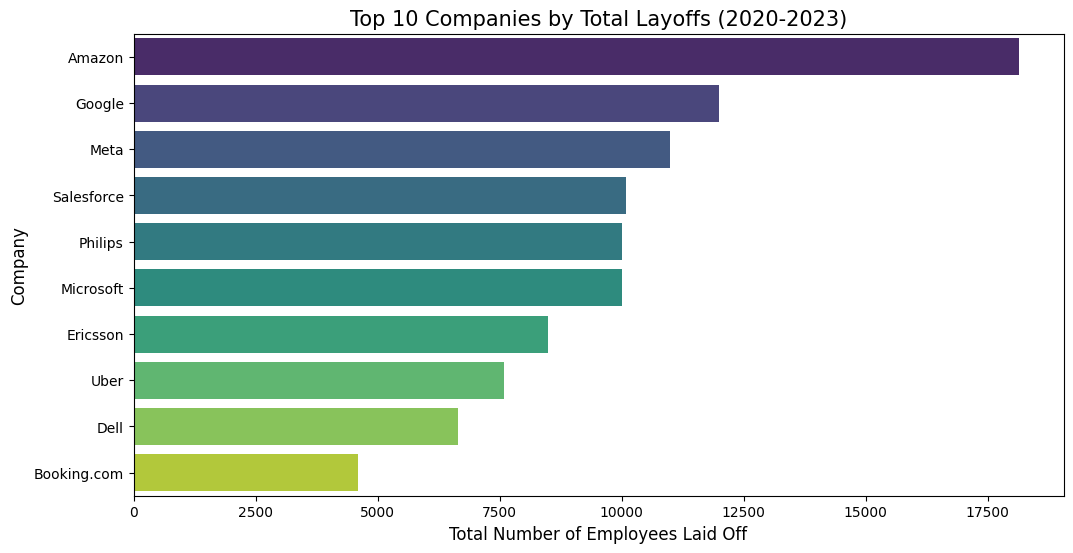

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the data using your SQL query
df_top_companies = run_query("""
    SELECT company, SUM(total_laid_off) as total
    FROM layoffs_staging2
    GROUP BY company
    ORDER BY total DESC
    LIMIT 10
""")

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_companies, x='total', y='company', palette='viridis')

# Add labels and title
plt.title('Top 10 Companies by Total Layoffs (2020-2023)', fontsize=15)
plt.xlabel('Total Number of Employees Laid Off', fontsize=12)
plt.ylabel('Company', fontsize=12)

plt.show()

**2. The Rolling Total of Layoffs (Line Chart)**



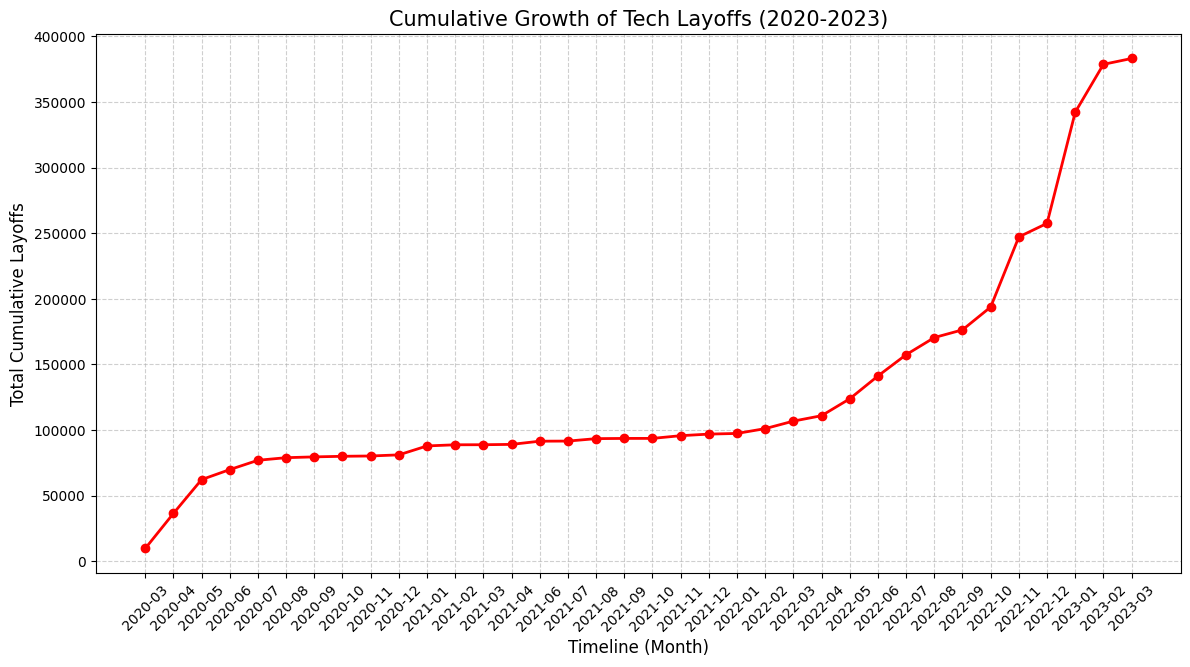

In [15]:
# Get the rolling total data
df_rolling = run_query("""
    WITH Rolling_Total AS (
        SELECT SUBSTRING(date, 1, 7) AS Month, SUM(total_laid_off) AS total_off
        FROM layoffs_staging2
        WHERE Month IS NOT NULL
        GROUP BY Month
        ORDER BY Month ASC
    )
    SELECT Month, SUM(total_off) OVER(ORDER BY Month) AS rolling_total
    FROM Rolling_Total
""")

# Create the plot
plt.figure(figsize=(14, 7))
plt.plot(df_rolling['Month'], df_rolling['rolling_total'], marker='o', color='red', linewidth=2)

# Rotate x-axis labels so they are readable
plt.xticks(rotation=45)

# Add labels and title
plt.title('Cumulative Growth of Tech Layoffs (2020-2023)', fontsize=15)
plt.xlabel('Timeline (Month)', fontsize=12)
plt.ylabel('Total Cumulative Layoffs', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Project Conclusion:**

Data Integrity: Successfully cleaned and standardized a raw dataset
of over 2,300 entries, resolving issues with duplicates, inconsistent naming, and incorrect date formats.

Key Insight: The analysis reveals a massive acceleration in layoffs starting in late 2022, peaking in early 2023.

Sector Impact: While the "Other" and "Consumer" industries saw high frequencies of layoffs, companies like Amazon and Google dominated the total volume of employees affected.




